# 1. Setup GPU

In [5]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

print("TensorFlow Version:", tf.__version__)
print("GPU Ditemukan:" if tf.config.list_physical_devices('GPU') else "GPU Tidak Ada")

Physical devices cannot be modified after being initialized
TensorFlow Version: 2.20.0
GPU Ditemukan:


# 2. Import Library

In [6]:
import os, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras import layers

# 3. Data Preparation & EDA

In [7]:
train_dir = 'Apple_Disease_Dataset/train'

class_names = os.listdir(train_dir)
apple_images = {class_name: os.listdir(os.path.join(train_dir, class_name)) for class_name in class_names}

## 3.1 Visualisasi

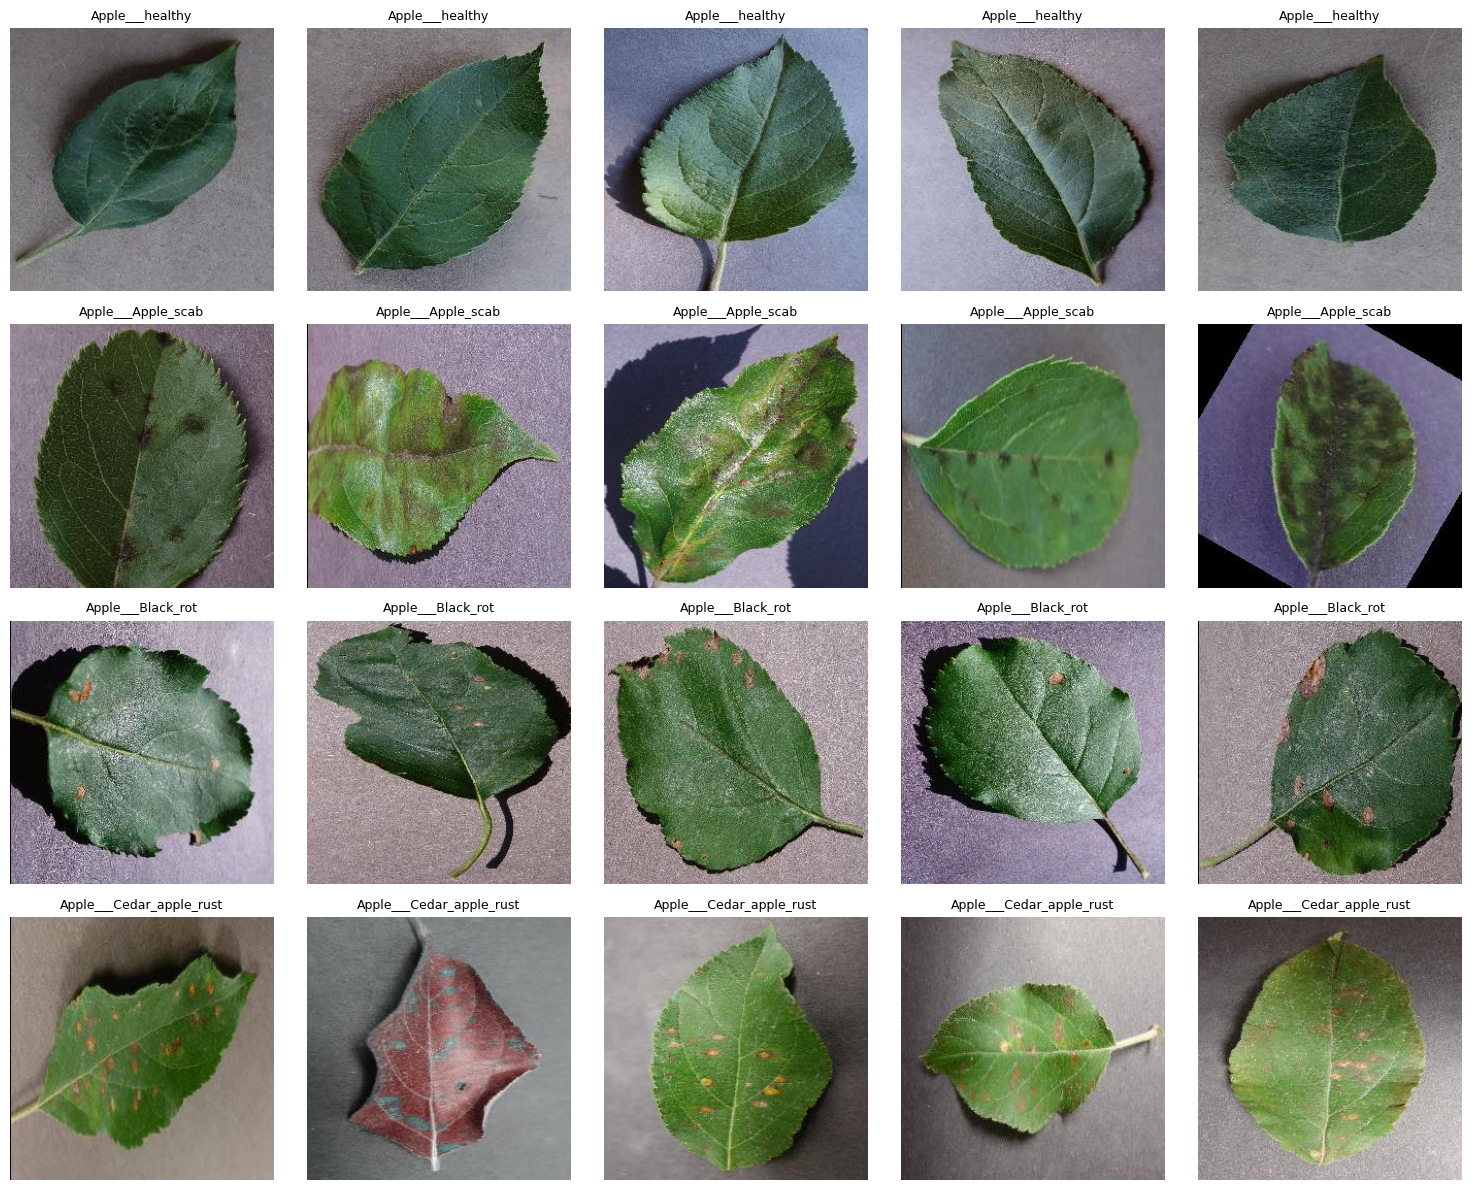

In [8]:
fig, axs = plt.subplots(len(class_names), 5, figsize=(15, 12))

for i, class_name in enumerate(class_names):
    random_images = random.sample(apple_images[class_name], 5)
    for j, image_name in enumerate(random_images):
        img_path = os.path.join(train_dir, class_name, image_name)
        img = Image.open(img_path)
        axs[i, j].imshow(img)
        axs[i, j].set_title(class_name, fontsize=9)
        axs[i, j].axis('off')

plt.tight_layout()
plt.show()

## 3.2 Distribusi Data

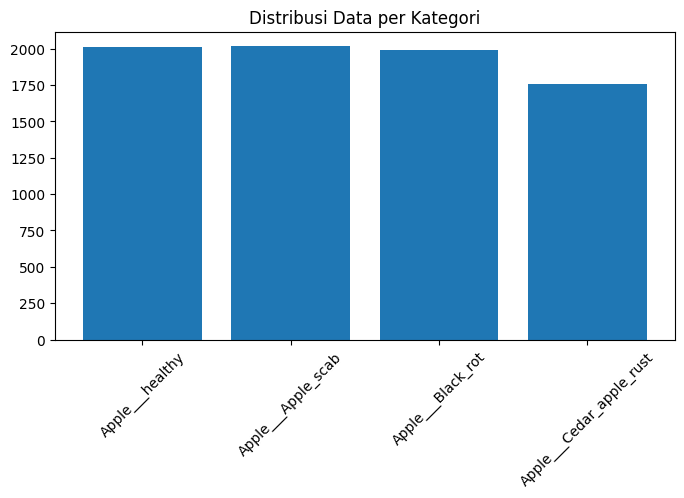

In [9]:
counts = [len(apple_images[c]) for c in class_names]

plt.figure(figsize=(8,4))
plt.bar(class_names, counts)
plt.title("Distribusi Data per Kategori")
plt.xticks(rotation=45)
plt.show()

# 4. Data Pipeline

In [10]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=8,
    label_mode='categorical'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=8,
    label_mode='categorical'
)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)

Found 7771 files belonging to 4 classes.
Using 6217 files for training.
Found 7771 files belonging to 4 classes.
Using 1554 files for validation.


# 5. Build Model (MobileNetV2 + Proper Preprocessing)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers
import tensorflow as tf

# 1. Augmentasi 
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(factor=0.2),
    layers.RandomContrast(factor=0.2),
], name="Sultan_Augmentation")

# 2. Panggil MobileNetV2
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Kunci dulu otaknya (Freeze phase) biar gak kaget
base_model.trainable = False  

# 3. Rakit Semua Jadi Satu Kesatuan (Model Utuh)
model = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input, name="MobileNet_Preprocess"),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax', name="Output_Prediksi")
])

# 4. Compile (Siap-siap Latihan)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Cek dalemannya
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Sultan_Augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNet_Preprocess (Lambda)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Prediksi (Dense)         │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 6. Training Phase 1 (Feature Extraction)

In [12]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15


2026-03-04 15:00:11.785204: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


778/778 ━━━━━━━━━━━━━━━━━━━━ 48s 49ms/step - accuracy: 0.8691 - loss: 0.3538 - val_accuracy: 0.9627 - val_loss: 0.1286
Epoch 2/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.9542 - loss: 0.1357 - val_accuracy: 0.9698 - val_loss: 0.0879
Epoch 3/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.9519 - loss: 0.1319 - val_accuracy: 0.9717 - val_loss: 0.0808
Epoch 4/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.9562 - loss: 0.1162 - val_accuracy: 0.9479 - val_loss: 0.1522
Epoch 5/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.9603 - loss: 0.1100 - val_accuracy: 0.9717 - val_loss: 0.0823
Epoch 6/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.9574 - loss: 0.1115 - val_accuracy: 0.9788 - val_loss: 0.0656
Epoch 7/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.9599 - loss: 0.1085 - val_accuracy: 0.9755 - val_loss: 0.0639
Epoch 8/15
778/778 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.9612 - loss: 0.1012 - val_accurac

# 7. Fine-Tuning Phase

In [13]:
# Unfreeze base model
base_model.trainable = True

# Bekukan layer awal (sisakan 30 layer terakhir)
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 65s 71ms/step - accuracy: 0.8760 - loss: 0.3900 - val_accuracy: 0.9801 - val_loss: 0.0497
Epoch 2/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.9146 - loss: 0.2483 - val_accuracy: 0.9897 - val_loss: 0.0288
Epoch 3/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - accuracy: 0.9220 - loss: 0.2420 - val_accuracy: 0.9871 - val_loss: 0.0321
Epoch 4/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - accuracy: 0.9421 - loss: 0.1663 - val_accuracy: 0.9903 - val_loss: 0.0240
Epoch 5/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.9460 - loss: 0.1456 - val_accuracy: 0.9923 - val_loss: 0.0231
Epoch 6/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.9501 - loss: 0.1503 - val_accuracy: 0.9929 - val_loss: 0.0178
Epoch 7/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.9543 - loss: 0.1291 - val_accuracy: 0.9942 - val_loss: 0.0145
Epoch 8/20
778/778 ━━━━━━━━━━━━━━━━━━━━ 60s 77ms/step - accuracy: 0.9501 - loss: 0.1346 - 

# 8. Plot Gabungan (Before vs After)

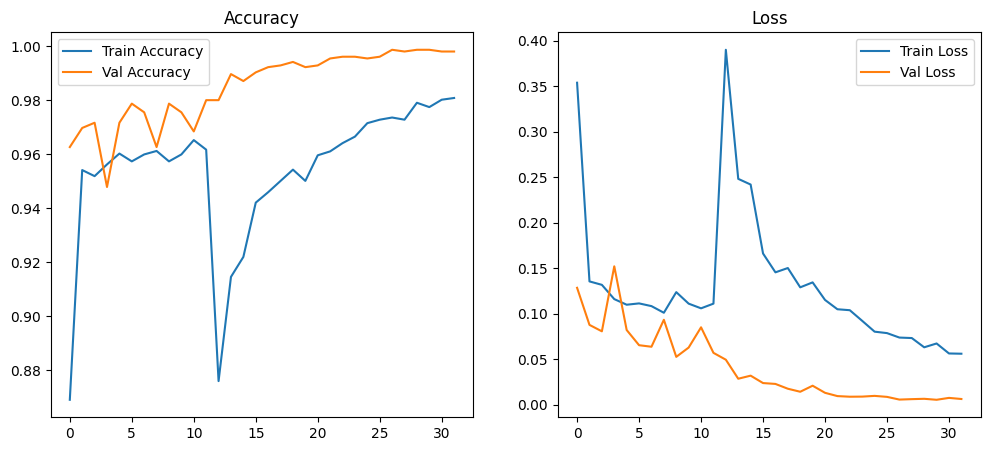

In [14]:
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']

loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

# 9. Confusion Matrix + Report

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━

2026-03-04 15:37:02.340094: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


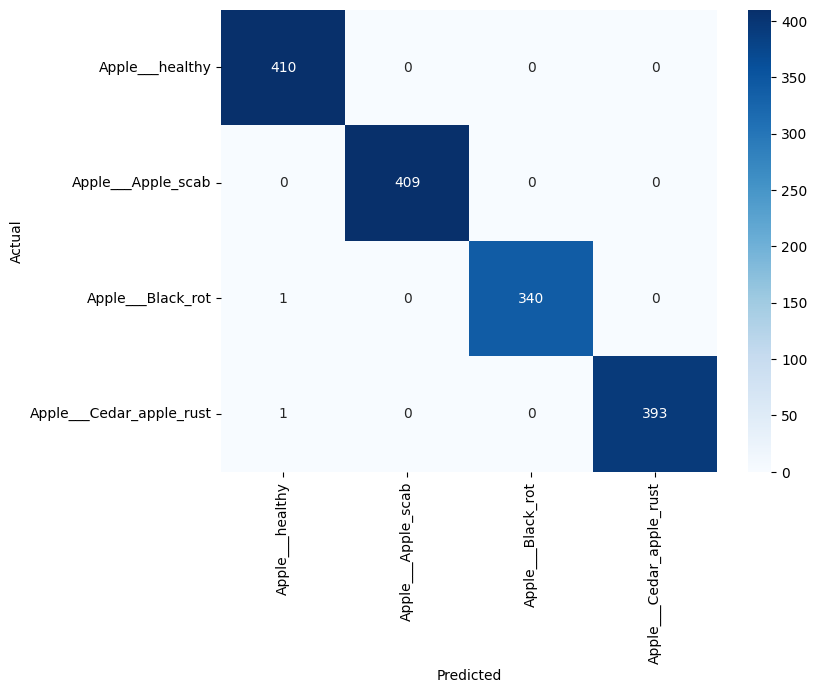

                          precision    recall  f1-score   support

         Apple___healthy       1.00      1.00      1.00       410
      Apple___Apple_scab       1.00      1.00      1.00       409
       Apple___Black_rot       1.00      1.00      1.00       341
Apple___Cedar_apple_rust       1.00      1.00      1.00       394

                accuracy                           1.00      1554
               macro avg       1.00      1.00      1.00      1554
            weighted avg       1.00      1.00      1.00      1554



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

# 10. Save Model

In [ ]:
# Save model keras
model.save("apple_disease_robust.keras")
print("✅ Model Sultan berhasil di-save dan siap dibawa ke Streamlit!")

✅ Model Sultan berhasil di-save dan siap dibawa ke Streamlit!


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("⏳ Memulai konversi ke TFLite...")

# 1. Load model dengan "Kunci Jawaban" dan buka gembok keamanannya
model_keras = tf.keras.models.load_model(
    "apple_disease_robust.keras",
    custom_objects={"preprocess_input": preprocess_input},
    safe_mode=False  # <-- Mantra sakti buat ngizinin Augmentasi dibaca
)

# 2. Siapin mesin kompresornya
converter = tf.lite.TFLiteConverter.from_keras_model(model_keras)

# Kasih izin mesin kompresor buat ngebaca operasi Lambda (Preprocess)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS, 
    tf.lite.OpsSet.SELECT_TF_OPS
]

# Eksekusi kompresi
tflite_model = converter.convert()

# 3. Save hasil kompresannya jadi file baru
with open("apple_disease_robust.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ SUKSES! Model telah di konversi ke TFLite")

⏳ Memulai konversi ke TFLite...
INFO:tensorflow:Assets written to: /tmp/tmp9ado6pi1/assets


INFO:tensorflow:Assets written to: /tmp/tmp9ado6pi1/assets


Saved artifact at '/tmp/tmp9ado6pi1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133643212302720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133643212382704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133643212551472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133643212550944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133643212545312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133643212553232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133643212933952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133643212939408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133643212937648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133643212937824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1336432129434

W0000 00:00:1772944366.144386    1728 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772944366.144524    1728 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-08 11:32:46.145261: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp9ado6pi1
2026-03-08 11:32:46.154693: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-08 11:32:46.154726: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp9ado6pi1
I0000 00:00:1772944366.292457    1728 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-03-08 11:32:46.310367: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-08 11:32:47.110055: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp9ado6pi1
2026-03-08 11:32:47.270622: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 